In [1]:
!wget http://cs231n.stanford.edu/tiny-imagenet-200.zip
!unzip tiny-imagenet-200.zip


Streaming output truncated to the last 5000 lines.
  inflating: tiny-imagenet-200/val/images/val_3979.JPEG  
  inflating: tiny-imagenet-200/val/images/val_3963.JPEG  
  inflating: tiny-imagenet-200/val/images/val_7199.JPEG  
  inflating: tiny-imagenet-200/val/images/val_2752.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9687.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9407.JPEG  
  inflating: tiny-imagenet-200/val/images/val_3603.JPEG  
  inflating: tiny-imagenet-200/val/images/val_3412.JPEG  
  inflating: tiny-imagenet-200/val/images/val_6982.JPEG  
  inflating: tiny-imagenet-200/val/images/val_8496.JPEG  
  inflating: tiny-imagenet-200/val/images/val_7332.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9241.JPEG  
  inflating: tiny-imagenet-200/val/images/val_4196.JPEG  
  inflating: tiny-imagenet-200/val/images/val_5980.JPEG  
  inflating: tiny-imagenet-200/val/images/val_6697.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9969.JPEG  
  inflating: tiny-ima

✅ Setup complete, using device: cuda
✅ Validation set reorganized: only class folders remain
✅ Dataset reduced to 20 classes × 100 images each
Train samples: 2000, Val samples: 1000
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


✅ Model ready with Augmentation + Dropout + Weight Decay + Scheduler

Epoch 1/20
Train Loss: 2.5319, Train Acc: 27.05%
Val Acc: 33.70%

Epoch 2/20
Train Loss: 1.7791, Train Acc: 51.45%
Val Acc: 44.20%

Epoch 3/20
Train Loss: 1.7247, Train Acc: 52.65%
Val Acc: 42.40%

Epoch 4/20
Train Loss: 1.5248, Train Acc: 59.20%
Val Acc: 53.80%

Epoch 5/20
Train Loss: 1.1531, Train Acc: 67.05%
Val Acc: 55.60%

Epoch 6/20
Train Loss: 0.8057, Train Acc: 76.00%
Val Acc: 65.00%

Epoch 7/20
Train Loss: 0.6797, Train Acc: 78.85%
Val Acc: 65.40%

Epoch 8/20
Train Loss: 0.5928, Train Acc: 82.90%
Val Acc: 68.60%

Epoch 9/20
Train Loss: 0.5238, Train Acc: 84.15%
Val Acc: 66.70%

Epoch 10/20
Train Loss: 0.5060, Train Acc: 85.40%
Val Acc: 68.80%

Epoch 11/20
Train Loss: 0.4872, Train Acc: 85.55%
Val Acc: 69.70%

Epoch 12/20
Train Loss: 0.4593, Train Acc: 85.70%
Val Acc: 68.70%

Epoch 13/20
Train Loss: 0.4620, Train Acc: 85.25%
Val Acc: 70.20%

Epoch 14/20
Train Loss: 0.4326, Train Acc: 86.95%
Val Acc: 68.70%

E

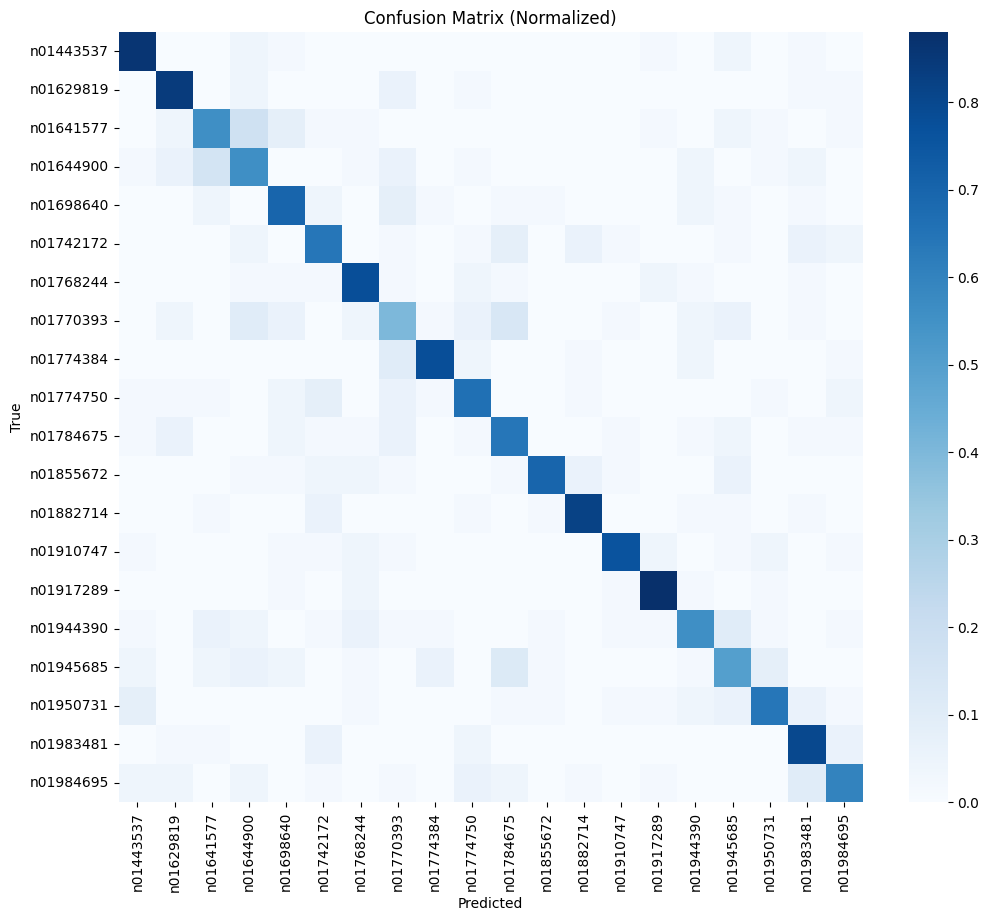


Classification Report:

              precision    recall  f1-score   support

   n01443537       0.77      0.86      0.81        50
   n01629819       0.75      0.84      0.79        50
   n01641577       0.61      0.56      0.58        50
   n01644900       0.49      0.56      0.52        50
   n01698640       0.66      0.70      0.68        50
   n01742172       0.62      0.64      0.63        50
   n01768244       0.71      0.78      0.74        50
   n01770393       0.43      0.40      0.41        50
   n01774384       0.85      0.78      0.81        50
   n01774750       0.66      0.66      0.66        50
   n01784675       0.58      0.64      0.61        50
   n01855672       0.88      0.70      0.78        50
   n01882714       0.82      0.82      0.82        50
   n01910747       0.84      0.76      0.80        50
   n01917289       0.83      0.88      0.85        50
   n01944390       0.65      0.56      0.60        50
   n01945685       0.51      0.50      0.51        50
  

In [ ]:
# -----------------------------
# 1. Imports and Setup
# -----------------------------
import os, shutil, random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Setup complete, using device:", device)

# -----------------------------
# 2. Reorganize Validation Set
# -----------------------------
val_dir = "/content/tiny-imagenet-200/val"
val_img_dir = os.path.join(val_dir, "images")
val_anno_file = os.path.join(val_dir, "val_annotations.txt")

with open(val_anno_file, "r") as f:
    for line in f:
        parts = line.strip().split("\t")
        img_name, cls = parts[0], parts[1]
        cls_folder = os.path.join(val_dir, cls)
        os.makedirs(cls_folder, exist_ok=True)
        src = os.path.join(val_img_dir, img_name)
        dst = os.path.join(cls_folder, img_name)
        if os.path.exists(src):
            shutil.move(src, dst)

if os.path.exists(val_img_dir):
    shutil.rmtree(val_img_dir)
if os.path.exists(val_anno_file):
    os.remove(val_anno_file)

print("✅ Validation set reorganized: only class folders remain")

# -----------------------------
# 3. Preprocessing (Stronger Augmentation)
# -----------------------------
transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -----------------------------
# 4. Reduce Dataset (optional: 20 classes × 100 images)
# -----------------------------
train_root = "/content/tiny-imagenet-200/train"
val_root   = "/content/tiny-imagenet-200/val"

classes_to_keep = sorted(os.listdir(train_root))[:20]

for root in [train_root, val_root]:
    for cls in os.listdir(root):
        if cls not in classes_to_keep:
            shutil.rmtree(os.path.join(root, cls))

for cls in classes_to_keep:
    cls_path = os.path.join(train_root, cls, "images")
    imgs = os.listdir(cls_path)
    keep = random.sample(imgs, min(100, len(imgs)))
    for img in imgs:
        if img not in keep:
            os.remove(os.path.join(cls_path, img))

print("✅ Dataset reduced to 20 classes × 100 images each")

# -----------------------------
# 5. Load Data
# -----------------------------
train_data = datasets.ImageFolder(root=train_root, transform=transform)
val_data   = datasets.ImageFolder(root=val_root, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_data)}, Val samples: {len(val_data)}")

# -----------------------------
# 6. Model Setup (ResNet18 + Dropout Head)
# -----------------------------
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(resnet.fc.in_features, len(classes_to_keep))
)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

print("✅ Model ready with Augmentation + Dropout + Weight Decay + Scheduler")

# -----------------------------
# 7. Training Loop (20 epochs)
# -----------------------------
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=20):
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100.0 * correct / total
        print(f"Train Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%")

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)

        val_acc = 100.0 * correct / total
        print(f"Val Acc: {val_acc:.2f}%")

        scheduler.step()

# -----------------------------
# 8. Train and Save
# -----------------------------
train_model(resnet, train_loader, val_loader, criterion, optimizer, scheduler, epochs=20)
torch.save(resnet.state_dict(), "resnet18_minitiny_augmented.pth")
print("💾 Model saved as resnet18_minitiny_augmented.pth")

# -----------------------------
# 9. Confusion Matrix + Per-Class Metrics
# -----------------------------
def evaluate_with_confusion(model, loader, classes):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_norm, annot=False, cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix (Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=classes))

# Run on validation set
class_names = train_data.classes
evaluate_with_confusion(resnet, val_loader, class_names)


In [ ]:
# Save
torch.save(resnet, "resnet_model.pth")
print("Model saved as resnet_model.pth")

Model saved as resnet_model.pth


In [ ]:


# ✅ Save only the state dict (recommended)
torch.save(resnet.state_dict(), "/content/drive/MyDrive/resnet18_state_dict.pth")

# ✅ Save the entire model object (quick but less portable)
torch.save(resnet, "/content/drive/MyDrive/resnet18_full_model.pth")
print("Model and weights saved in drive ")


Model and weights saved in drive 


In [2]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 92.3 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import faiss
import numpy as np
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 1. Preprocessing
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_root = "/content/tiny-imagenet-200/train"
train_data = datasets.ImageFolder(root=train_root, transform=transform)
loader = DataLoader(train_data, batch_size=64, shuffle=False)

# -----------------------------
# 2. Embedding Model (ResNet18 without classifier head)
# -----------------------------
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
embedding_model = nn.Sequential(*list(resnet.children())[:-1])  # remove FC
embedding_model = embedding_model.to(device)
embedding_model.eval()

# -----------------------------
# 3. Embedding Function
# -----------------------------
def get_embedding(imgs):
    with torch.no_grad():
        emb = embedding_model(imgs.to(device))   # [batch, 512, 1, 1]
        emb = torch.flatten(emb, 1)              # [batch, 512]
    return emb

# -----------------------------
# 4. Build FAISS Index
# -----------------------------
d = 512  # embedding dimension
index = faiss.IndexFlatIP(d)

all_embeddings = []
for imgs, _ in loader:
    emb = get_embedding(imgs)
    all_embeddings.append(emb.cpu().numpy())

all_embeddings = np.vstack(all_embeddings)
faiss.normalize_L2(all_embeddings)  # normalize for cosine similarity
index.add(all_embeddings)

print("✅ FAISS index built with", len(all_embeddings), "images")



✅ FAISS index built with 2000 images


In [ ]:
# -----------------------------
# 5. Query with One Image
# -----------------------------
def get_embedding_for_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)
    return get_embedding(img).cpu().numpy()

query_path = "/content/tiny-imagenet-200/test/images/test_101.JPEG"
query_emb = get_embedding_for_image(query_path)
faiss.normalize_L2(query_emb)

D, I = index.search(query_emb, k=5)  # top-5 results
print("Top-k indices:", I)
print("Cosine similarity scores:", D)


Top-k indices: [[1254 1212 1200 1232 1228]]
Cosine similarity scores: [[0.7003227  0.6963582  0.6794739  0.66125417 0.6610676 ]]


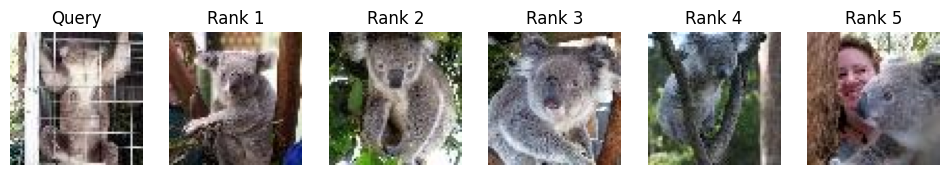

In [ ]:
import matplotlib.pyplot as plt

# Map FAISS indices back to dataset samples
image_paths = [sample[0] for sample in train_data.samples]  # list of file paths

def show_results(query_path, indices):
    # Show query image
    query_img = Image.open(query_path).convert("RGB")
    plt.figure(figsize=(12, 3))
    plt.subplot(1, len(indices)+1, 1)
    plt.imshow(query_img)
    plt.title("Query")
    plt.axis("off")

    # Show retrieved images
    for i, idx in enumerate(indices):
        img = Image.open(image_paths[idx]).convert("RGB")
        plt.subplot(1, len(indices)+1, i+2)
        plt.imshow(img)
        plt.title(f"Rank {i+1}")
        plt.axis("off")

    plt.show()

# Example usage
show_results(query_path, I[0])


                              LOAD THE FINE TUNED MODEL WITH THE LEARNED WEIGHTS

In [4]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import faiss
import numpy as np
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 1. Preprocessing
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_root = "/content/tiny-imagenet-200/train"
train_data = datasets.ImageFolder(root=train_root, transform=transform)
loader = DataLoader(train_data, batch_size=64, shuffle=False)

# -----------------------------
# 2. Embedding Model (ResNet18 without classifier head)
# -----------------------------
checkpoint_path = "/content/drive/MyDrive/resnet18_full_model.pth"

resnet_finetuned = torch.load(checkpoint_path, map_location=device, weights_only=False)

resnet_finetuned = resnet_finetuned.to(device)
resnet_finetuned.eval()

print("✅ Fine-tuned ResNet18 loaded from full model")



embedding_model1 = nn.Sequential(*list(resnet_finetuned.children())[:-1])  # remove FC
embedding_model1 = embedding_model1.to(device)
embedding_model1.eval()

# -----------------------------
# 3. Embedding Function
# -----------------------------
def get_embedding(imgs):
    with torch.no_grad():
        emb = embedding_model1(imgs.to(device))   # [batch, 512, 1, 1]
        emb = torch.flatten(emb, 1)              # [batch, 512]
    return emb

# -----------------------------
# 4. Build FAISS Index
# -----------------------------
d = 512  # embedding dimension
index = faiss.IndexFlatIP(d)

all_embeddings = []
for imgs, _ in loader:
    emb = get_embedding(imgs)
    all_embeddings.append(emb.cpu().numpy())

all_embeddings = np.vstack(all_embeddings)
faiss.normalize_L2(all_embeddings)  # normalize for cosine similarity
index.add(all_embeddings)

print("✅ FAISS index built with", len(all_embeddings), "images")



✅ Fine-tuned ResNet18 loaded from full model
✅ FAISS index built with 100000 images


In [5]:
# -----------------------------
# 5. Query with One Image
# -----------------------------
def get_embedding_for_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)
    return get_embedding(img).cpu().numpy()

query_path = "/content/tiny-imagenet-200/test/images/test_101.JPEG"
query_emb = get_embedding_for_image(query_path)
faiss.normalize_L2(query_emb)

D, I = index.search(query_emb, k=5)  # top-5 results
print("Top-k indices:", I)
print("Cosine similarity scores:", D)


Top-k indices: [[24314 28465 16628 27644  6441]]
Cosine similarity scores: [[0.7241844  0.7164354  0.71203315 0.7105104  0.70755094]]


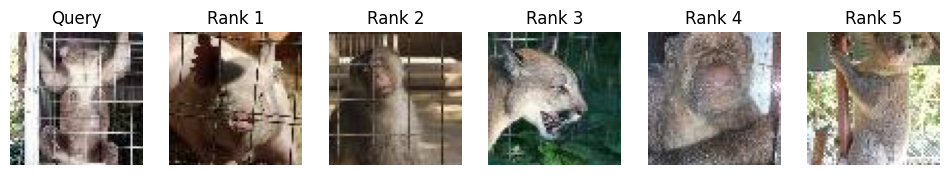

In [6]:
import matplotlib.pyplot as plt

# Map FAISS indices back to dataset samples
image_paths = [sample[0] for sample in train_data.samples]  # list of file paths

def show_results(query_path, indices):
    # Show query image
    query_img = Image.open(query_path).convert("RGB")
    plt.figure(figsize=(12, 3))
    plt.subplot(1, len(indices)+1, 1)
    plt.imshow(query_img)
    plt.title("Query")
    plt.axis("off")

    # Show retrieved images
    for i, idx in enumerate(indices):
        img = Image.open(image_paths[idx]).convert("RGB")
        plt.subplot(1, len(indices)+1, i+2)
        plt.imshow(img)
        plt.title(f"Rank {i+1}")
        plt.axis("off")

    plt.show()

# Example usage
show_results(query_path, I[0])
